In [6]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict ,Annotated,Literal
from dotenv import load_dotenv
import os
from pydantic import BaseModel ,Field 
import operator
from langchain_core.messages import SystemMessage, HumanMessage,BaseMessage
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.chat_models import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage
    

In [7]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    message : Annotated[list[BaseMessage],add_messages]




In [14]:
api_key = os.getenv('GOOGLE_API_KEY')
# llm = ChatOllama(
#     model="mistral",
#     temperature=0.7
# )

llm = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash',
    google_api_key = api_key
)


In [16]:

def ChatNode(state:ChatState) -> ChatState:
    ## take the user query from the state
    messages = state['message']

    ## send to the llm
    response = llm.invoke(messages)

    ## response store state
    return {'message':[response]}


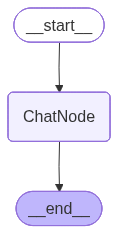

In [17]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node("ChatNode",ChatNode)

graph.add_edge(START,"ChatNode")
graph.add_edge("ChatNode",END)

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [18]:
# initial_state = {
#     'message':[HumanMessage(content="whar is the capital of india")]
# }

# workflow.invoke(initial_state)['message'][-1].content

In [19]:
thread_id = '1'

while True:
    user_message = input("Type here :")
    print("User Message : ",user_message)
    if user_message.strip().lower() in ['exit','quit','by','bye']:
        break
    else:
        config = {'configurable':{'thread_id':thread_id}}
        response = workflow.invoke({'message':[HumanMessage(content=user_message)]},config=config)
        print('AI : ',response['message'][-1].content)



User Message :  hy
AI :  Hi there! How can I help you today?
User Message :  exit


In [ ]:
workflow.get_state(config=config)